# 🏆 Playoff Odds & Standings Projections

## Overview
Uses 50,000 Monte Carlo simulations to project final standings after the current week.

## Methodology
1. Load current standings (wins, losses, points scored)
2. Load week's matchups
3. For each of 50,000 simulations:
   - Determine matchup winners based on simulated points
   - Update records and total points
   - Rank teams by: (1) Win-Loss record, (2) Points scored (tiebreaker)
   - Record final standings
4. Calculate probability matrix for each team finishing in each position
5. Generate betting odds for playoff scenarios

## Outputs
- Standings probability matrix
- #1 seed odds
- Top 8 (playoff) odds
- Visualizations


---
## 📦 Setup & Configuration


In [1]:
import numpy as np
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set style for elegant plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Configuration
CURRENT_WEEK = 14
N_SIMULATIONS = 50000
LEAGUE_ID = '1226433368405585920'  # Main league
PLAYOFF_CUTOFF = 8  # Top 8 make playoffs

# Use absolute paths (this notebook is at backend/notebooks/)
NOTEBOOK_DIR = Path(r"C:\Users\Samer Faizi\Documents\Claude Model\backend\notebooks")
BACKEND_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = BACKEND_DIR.parent

# Database paths
DB_LEAGUE_PATH = str(BACKEND_DIR / "data" / "databases" / "league.db")
DB_MONTECARLO_PATH = str(BACKEND_DIR / "data" / "databases" / "montecarlo.db")
DB_ODDS_PATH = str(BACKEND_DIR / "data" / "databases" / "odds.db")

# Output directories
CSV_DIR = BACKEND_DIR / "data" / "csv"
IMAGES_DIR = BACKEND_DIR / "data" / "images"

print(f"✅ Week: {CURRENT_WEEK}")
print(f"✅ Simulations: {N_SIMULATIONS:,}")
print(f"✅ Playoff cutoff: Top {PLAYOFF_CUTOFF}")
print(f"\n📁 League DB: {DB_LEAGUE_PATH}")
print(f"📁 Monte Carlo DB: {DB_MONTECARLO_PATH}")
print(f"📁 Odds DB: {DB_ODDS_PATH}")


✅ Week: 14
✅ Simulations: 50,000
✅ Playoff cutoff: Top 8

📁 League DB: C:\Users\Samer Faizi\Documents\Claude Model\backend\data\databases\league.db
📁 Monte Carlo DB: C:\Users\Samer Faizi\Documents\Claude Model\backend\data\databases\montecarlo.db
📁 Odds DB: C:\Users\Samer Faizi\Documents\Claude Model\backend\data\databases\odds.db


---
## 📊 Load Current Standings & Matchups


In [2]:
# Load current standings
conn_league = sqlite3.connect(DB_LEAGUE_PATH)

standings_query = f"""
    SELECT 
        r.roster_id as team_id,
        COALESCE(r.team_name, 'Team ' || r.roster_id) as team_name,
        u.display_name as owner,
        r.wins,
        r.losses,
        r.ties,
        r.fpts + r.fpts_decimal as total_points
    FROM rosters r
    JOIN users u ON r.owner_id = u.user_id
    WHERE r.league_id = '{LEAGUE_ID}'
    ORDER BY r.wins DESC, (r.fpts + r.fpts_decimal) DESC
"""
df_standings = pd.read_sql_query(standings_query, conn_league)

# Load matchups for current week
matchups_query = f"""
    SELECT roster_id, matchup_id_number
    FROM matchups
    WHERE week = {CURRENT_WEEK}
    ORDER BY matchup_id_number
"""
df_matchups = pd.read_sql_query(matchups_query, conn_league)
conn_league.close()

# Build matchup pairs
matchup_pairs = []
for matchup_id in df_matchups['matchup_id_number'].unique():
    teams = df_matchups[df_matchups['matchup_id_number'] == matchup_id]['roster_id'].tolist()
    if len(teams) == 2:
        matchup_pairs.append(tuple(teams))

print("📋 CURRENT STANDINGS (Before Week {}):".format(CURRENT_WEEK))
print("="*70)
print(f"{'Rank':<6}{'Team':<25}{'Owner':<20}{'Record':<10}{'Points'}")
print("-"*70)
for i, row in df_standings.iterrows():
    record = f"{row['wins']}-{row['losses']}-{row['ties']}"
    print(f"{i+1:<6}{row['team_name']:<25}{row['owner']:<20}{record:<10}{row['total_points']:.1f}")

print(f"\n🎮 Week {CURRENT_WEEK} Matchups:")
for t1, t2 in matchup_pairs:
    owner1 = df_standings[df_standings['team_id'] == t1]['owner'].values[0]
    owner2 = df_standings[df_standings['team_id'] == t2]['owner'].values[0]
    print(f"  • {owner1} vs {owner2}")


📋 CURRENT STANDINGS (Before Week 14):
Rank  Team                     Owner               Record    Points
----------------------------------------------------------------------
1     Team 1                   xavierking4         9-4-0     1649.0
2     Team 8                   sahirsyed30         8-5-0     1743.0
3     Team 3                   amir812             8-5-0     1709.0
4     Team 5                   TBK41               8-5-0     1645.0
5     Team 10                  monkeyman966699696  8-5-0     1583.0
6     Team 2                   asadrafique         7-6-0     1612.0
7     Team 6                   Jibraan             7-6-0     1520.0
8     Team 12                  sfaizi24            7-6-0     1515.0
9     Team 11                  Ammady              6-7-0     1421.0
10    Team 9                   Bilal879            5-8-0     1419.0
11    Team 7                   mehdidrissi         4-9-0     1470.0
12    Team 4                   umarrahman30        1-12-0    1315.0

🎮 Week

---
## 🎲 Load Monte Carlo Simulations


In [3]:
# Load simulation results
conn_mc = sqlite3.connect(DB_MONTECARLO_PATH)

# Get the latest run_id for this week
run_query = f"""
    SELECT run_id FROM simulation_runs 
    WHERE week = {CURRENT_WEEK} 
    ORDER BY created_at DESC LIMIT 1
"""
run_id = pd.read_sql_query(run_query, conn_mc)['run_id'].values[0]
print(f"📊 Using simulation run: {run_id}")

# Load all simulations
sims_query = f"""
    SELECT sim_id, team_id, team_name, owner, total_points
    FROM monte_carlo_simulations
    WHERE week = {CURRENT_WEEK} AND run_id = '{run_id}'
    ORDER BY sim_id, team_id
"""
df_sims = pd.read_sql_query(sims_query, conn_mc)
conn_mc.close()

# Pivot to get simulations as columns
n_sims = df_sims['sim_id'].nunique()
n_teams = df_sims['team_id'].nunique()

print(f"✅ Loaded {len(df_sims):,} simulation records")
print(f"   • {n_sims:,} simulations")
print(f"   • {n_teams} teams")

# Create team info lookup
team_info = df_sims[['team_id', 'team_name', 'owner']].drop_duplicates().set_index('team_id').to_dict('index')


📊 Using simulation run: seed_1738_20251202_233545
✅ Loaded 600,000 simulation records
   • 50,000 simulations
   • 12 teams


---
## 🏆 Simulate Standings After Each Week


In [4]:
# Prepare current standings data
current_standings = {}
for _, row in df_standings.iterrows():
    current_standings[row['team_id']] = {
        'wins': row['wins'],
        'losses': row['losses'],
        'points': row['total_points'],
        'owner': row['owner'],
        'team_name': row['team_name']
    }

# Pivot simulations for fast access
# Create a matrix: sim_id x team_id -> points
sim_matrix = df_sims.pivot(index='sim_id', columns='team_id', values='total_points')

print("🔄 Simulating standings for {:,} scenarios...".format(n_sims))

# Track standings: standings_count[team_id][position] = count
standings_count = {team_id: {pos: 0 for pos in range(1, 13)} for team_id in current_standings.keys()}

# Process each simulation
for sim_id in range(n_sims):
    if sim_id % 10000 == 0:
        print(f"  Processing simulation {sim_id:,}...")
    
    # Get simulated points for this run
    sim_points = sim_matrix.loc[sim_id]
    
    # Build post-week standings
    post_week = []
    for team_id, data in current_standings.items():
        new_wins = data['wins']
        new_losses = data['losses']
        new_points = data['points'] + sim_points[team_id]
        
        post_week.append({
            'team_id': team_id,
            'wins': new_wins,
            'losses': new_losses,
            'points': new_points
        })
    
    # Determine matchup winners and update records
    for t1, t2 in matchup_pairs:
        pts1 = sim_points[t1]
        pts2 = sim_points[t2]
        
        # Find team entries and update
        for entry in post_week:
            if entry['team_id'] == t1:
                if pts1 > pts2:
                    entry['wins'] += 1
                else:
                    entry['losses'] += 1
            elif entry['team_id'] == t2:
                if pts2 > pts1:
                    entry['wins'] += 1
                else:
                    entry['losses'] += 1
    
    # Sort by wins (desc), then points (desc)
    post_week.sort(key=lambda x: (-x['wins'], -x['points']))
    
    # Record standings
    for position, entry in enumerate(post_week, 1):
        standings_count[entry['team_id']][position] += 1

print("\n✅ Standings simulation complete!")


🔄 Simulating standings for 50,000 scenarios...
  Processing simulation 0...
  Processing simulation 10,000...
  Processing simulation 20,000...
  Processing simulation 30,000...
  Processing simulation 40,000...

✅ Standings simulation complete!


---
## 📈 Create Standings Probability Matrix


In [5]:
# Build the probability matrix
teams = list(current_standings.keys())
positions = list(range(1, 13))

# Create DataFrame with team owners as index
prob_matrix = pd.DataFrame(index=[current_standings[t]['owner'] for t in teams],
                           columns=positions)

team_id_to_owner = {t: current_standings[t]['owner'] for t in teams}

for team_id in teams:
    owner = team_id_to_owner[team_id]
    for pos in positions:
        prob_matrix.loc[owner, pos] = standings_count[team_id][pos] / n_sims * 100

# Sort by most likely to be #1
prob_matrix = prob_matrix.sort_values(by=1, ascending=False)

print("📊 STANDINGS PROBABILITY MATRIX (%)")
print("="*100)
print(prob_matrix.round(1).to_string())

# Also create raw counts version
counts_matrix = pd.DataFrame(index=[current_standings[t]['owner'] for t in teams],
                             columns=positions)
for team_id in teams:
    owner = team_id_to_owner[team_id]
    for pos in positions:
        counts_matrix.loc[owner, pos] = standings_count[team_id][pos]

counts_matrix = counts_matrix.loc[prob_matrix.index]  # Same sort order


📊 STANDINGS PROBABILITY MATRIX (%)
                        1       2       3       4       5       6       7       8       9       10      11     12
sahirsyed30          41.82  32.508   9.812   11.01   4.844   0.006     0.0     0.0     0.0     0.0     0.0    0.0
xavierking4         39.836   8.668    27.5  22.176    1.82     0.0     0.0     0.0     0.0     0.0     0.0    0.0
amir812             10.574  26.724  22.332  22.838  17.312    0.22     0.0     0.0     0.0     0.0     0.0    0.0
TBK41                7.542   28.08  22.838  15.584  21.982   3.958   0.016     0.0     0.0     0.0     0.0    0.0
monkeyman966699696   0.228   4.016  17.398  25.472  28.992  21.406    2.42   0.068     0.0     0.0     0.0    0.0
asadrafique            0.0   0.004   0.098    2.79  22.802  42.974  22.306   9.026     0.0     0.0     0.0    0.0
Jibraan                0.0     0.0     0.0    0.07   1.538  15.362  41.052  41.662   0.316     0.0     0.0    0.0
sfaizi24               0.0     0.0   0.022    0.06   

---
## 🎰 Calculate Playoff Odds


In [6]:
def prob_to_american_odds(prob: float) -> str:
    """Convert probability to American odds format."""
    if prob <= 0 or prob >= 1:
        return "N/A"
    if prob >= 0.5:
        odds = -int(round(prob / (1 - prob) * 100))
        return f"{odds:+d}"
    else:
        odds = int(round((1 - prob) / prob * 100))
        return f"+{odds}"

# Calculate key probabilities
playoff_odds = []

for team_id in teams:
    owner = current_standings[team_id]['owner']
    team_name = current_standings[team_id]['team_name']
    
    # #1 seed probability
    first_place_prob = standings_count[team_id][1] / n_sims
    
    # Top 8 (playoff) probability
    top8_count = sum(standings_count[team_id][pos] for pos in range(1, PLAYOFF_CUTOFF + 1))
    top8_prob = top8_count / n_sims
    
    # Miss playoffs probability
    miss_count = sum(standings_count[team_id][pos] for pos in range(PLAYOFF_CUTOFF + 1, 13))
    miss_prob = miss_count / n_sims
    
    playoff_odds.append({
        'team_id': team_id,
        'team_name': team_name,
        'owner': owner,
        'first_place_prob': first_place_prob,
        'first_place_odds': prob_to_american_odds(first_place_prob),
        'top8_prob': top8_prob,
        'top8_odds': prob_to_american_odds(top8_prob),
        'miss_playoffs_prob': miss_prob
    })

df_playoff_odds = pd.DataFrame(playoff_odds)
df_playoff_odds = df_playoff_odds.sort_values('first_place_prob', ascending=False)

print("🏆 PLAYOFF ODDS SUMMARY")
print("="*80)
print(f"{'Owner':<22}{'#1 Seed %':>12}{'#1 Odds':>12}{'Top 8 %':>12}{'Top 8 Odds':>12}")
print("-"*80)
for _, row in df_playoff_odds.iterrows():
    print(f"{row['owner']:<22}{row['first_place_prob']*100:>11.1f}%{row['first_place_odds']:>12}"
          f"{row['top8_prob']*100:>11.1f}%{row['top8_odds']:>12}")


🏆 PLAYOFF ODDS SUMMARY
Owner                    #1 Seed %     #1 Odds     Top 8 %  Top 8 Odds
--------------------------------------------------------------------------------
sahirsyed30                  41.8%        +139      100.0%         N/A
xavierking4                  39.8%        +151      100.0%         N/A
amir812                      10.6%        +846      100.0%         N/A
TBK41                         7.5%       +1226      100.0%         N/A
monkeyman966699696            0.2%      +43760      100.0%         N/A
asadrafique                   0.0%         N/A      100.0%         N/A
Jibraan                       0.0%         N/A       99.7%      -31546
sfaizi24                      0.0%         N/A       99.1%      -11161
Ammady                        0.0%         N/A        1.2%       +8206
Bilal879                      0.0%         N/A        0.0%         N/A
mehdidrissi                   0.0%         N/A        0.0%         N/A
umarrahman30                  0.0%         N

---
## 💾 Save to Database


In [7]:
# Create standings odds tables in odds.db
conn_odds = sqlite3.connect(DB_ODDS_PATH)
cursor = conn_odds.cursor()

# Create tables for playoff odds
cursor.execute("""
    CREATE TABLE IF NOT EXISTS betting_odds_first_place (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        run_id TEXT NOT NULL,
        week INTEGER NOT NULL,
        team_id INTEGER NOT NULL,
        team_name TEXT NOT NULL,
        owner TEXT NOT NULL,
        probability REAL NOT NULL,
        american_odds TEXT NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        UNIQUE(run_id, week, team_id)
    )
""")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS betting_odds_make_playoffs (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        run_id TEXT NOT NULL,
        week INTEGER NOT NULL,
        team_id INTEGER NOT NULL,
        team_name TEXT NOT NULL,
        owner TEXT NOT NULL,
        probability REAL NOT NULL,
        american_odds TEXT NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        UNIQUE(run_id, week, team_id)
    )
""")

# Create table for full standings matrix
cursor.execute("""
    CREATE TABLE IF NOT EXISTS standings_probability_matrix (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        run_id TEXT NOT NULL,
        week INTEGER NOT NULL,
        team_id INTEGER NOT NULL,
        team_name TEXT NOT NULL,
        owner TEXT NOT NULL,
        position INTEGER NOT NULL,
        probability REAL NOT NULL,
        count INTEGER NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        UNIQUE(run_id, week, team_id, position)
    )
""")

conn_odds.commit()
print("✅ Database tables created")

# Generate run ID
run_id = f"standings_{CURRENT_WEEK}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

# Delete existing data for this week (to allow re-runs)
cursor.execute("DELETE FROM betting_odds_first_place WHERE week = ?", (CURRENT_WEEK,))
cursor.execute("DELETE FROM betting_odds_make_playoffs WHERE week = ?", (CURRENT_WEEK,))
cursor.execute("DELETE FROM standings_probability_matrix WHERE week = ?", (CURRENT_WEEK,))
conn_odds.commit()

# Insert first place odds (only for teams with 1-99% chance)
first_place_inserted = 0
for _, row in df_playoff_odds.iterrows():
    prob = row['first_place_prob']
    if 0.01 <= prob <= 0.99:  # Only 1-99% range
        cursor.execute("""
            INSERT OR REPLACE INTO betting_odds_first_place 
            (run_id, week, team_id, team_name, owner, probability, american_odds)
            VALUES (?, ?, ?, ?, ?, ?, ?)
        """, (run_id, CURRENT_WEEK, row['team_id'], row['team_name'], 
              row['owner'], prob, row['first_place_odds']))
        first_place_inserted += 1

# Insert make playoffs odds (only for teams with 1-99% chance)
playoffs_inserted = 0
for _, row in df_playoff_odds.iterrows():
    prob = row['top8_prob']
    if 0.01 <= prob <= 0.99:  # Only 1-99% range
        cursor.execute("""
            INSERT OR REPLACE INTO betting_odds_make_playoffs 
            (run_id, week, team_id, team_name, owner, probability, american_odds)
            VALUES (?, ?, ?, ?, ?, ?, ?)
        """, (run_id, CURRENT_WEEK, row['team_id'], row['team_name'], 
              row['owner'], prob, row['top8_odds']))
        playoffs_inserted += 1

# Insert full standings matrix
matrix_inserted = 0
for team_id in teams:
    owner = current_standings[team_id]['owner']
    team_name = current_standings[team_id]['team_name']
    for pos in positions:
        count = standings_count[team_id][pos]
        prob = count / n_sims
        cursor.execute("""
            INSERT OR REPLACE INTO standings_probability_matrix
            (run_id, week, team_id, team_name, owner, position, probability, count)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (run_id, CURRENT_WEEK, team_id, team_name, owner, pos, prob, count))
        matrix_inserted += 1

conn_odds.commit()
conn_odds.close()

print(f"\n📊 Data saved to odds.db:")
print(f"   • Run ID: {run_id}")
print(f"   • First place odds: {first_place_inserted} teams (1-99% range)")
print(f"   • Make playoffs odds: {playoffs_inserted} teams (1-99% range)")
print(f"   • Standings matrix: {matrix_inserted} entries")


✅ Database tables created

📊 Data saved to odds.db:
   • Run ID: standings_14_20251203_000147
   • First place odds: 4 teams (1-99% range)
   • Make playoffs odds: 1 teams (1-99% range)
   • Standings matrix: 144 entries


---
## 📊 Visualization: Standings Probability Heatmap


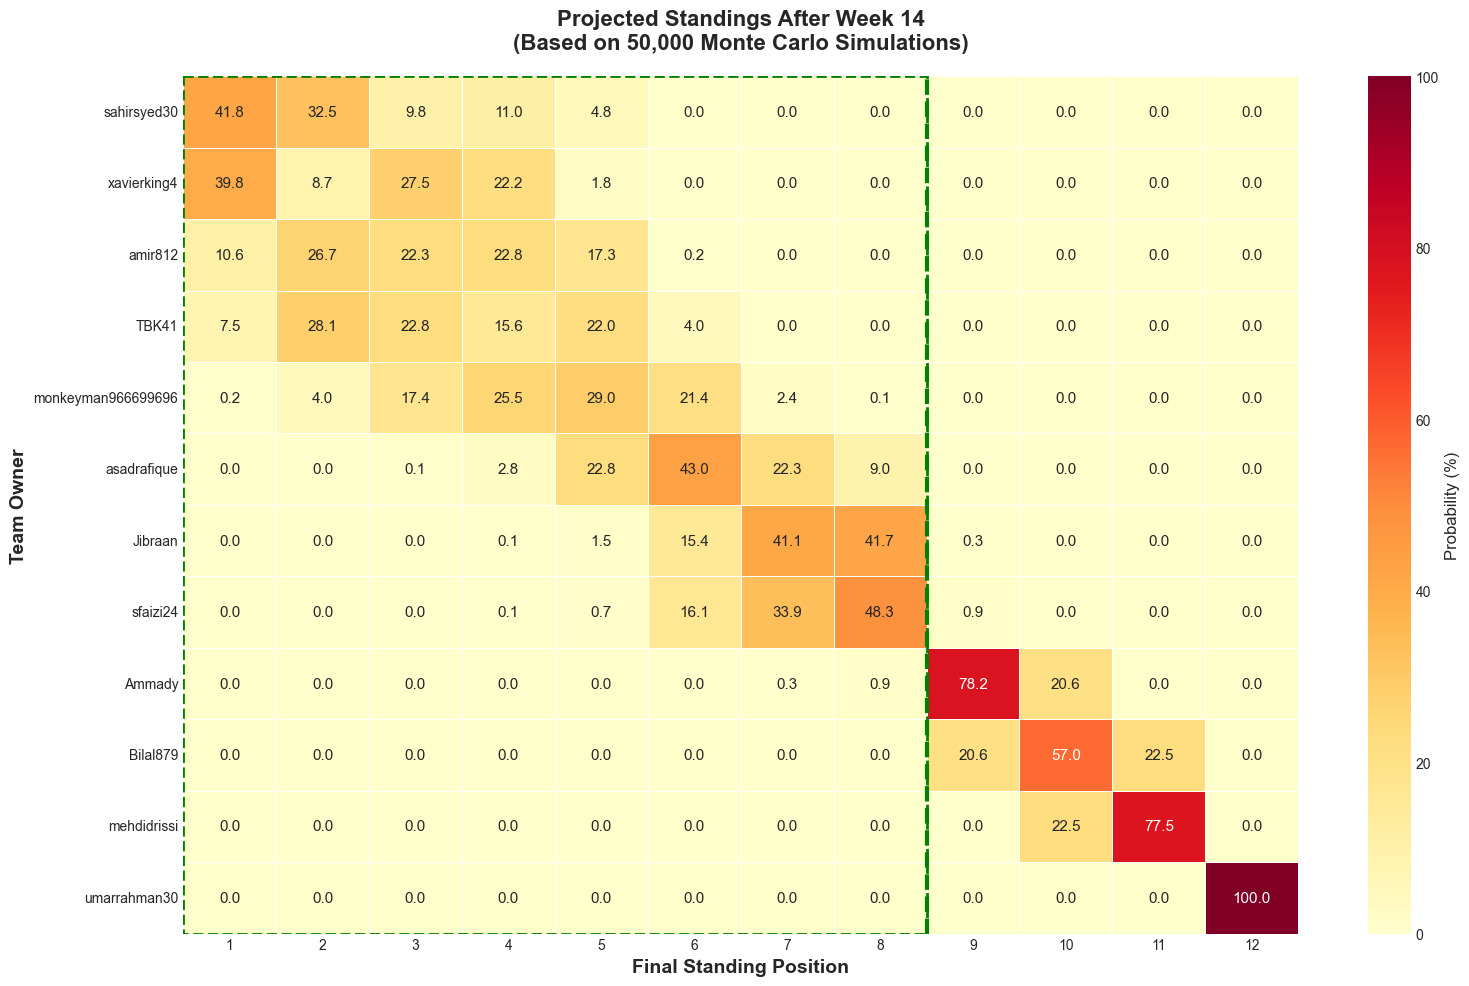

💾 Saved: standings_heatmap_week_14.png


In [9]:
# Create heatmap of standings probabilities
fig, ax = plt.subplots(figsize=(16, 10))

# Plot heatmap
sns.heatmap(prob_matrix.astype(float), 
            annot=True, 
            fmt='.1f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Probability (%)'},
            linewidths=0.5,
            ax=ax,
            vmin=0,
            vmax=prob_matrix.max().max())

# Add playoff line
ax.axvline(x=PLAYOFF_CUTOFF, color='green', linewidth=3, linestyle='--', label='Playoff Cutoff')

ax.set_xlabel('Final Standing Position', fontsize=14, fontweight='bold')
ax.set_ylabel('Team Owner', fontsize=14, fontweight='bold')
ax.set_title(f'Projected Standings After Week {CURRENT_WEEK}\n(Based on {N_SIMULATIONS:,} Monte Carlo Simulations)', 
             fontsize=16, fontweight='bold', pad=20)

# Color the playoff zone
ax.add_patch(plt.Rectangle((0, 0), PLAYOFF_CUTOFF, len(prob_matrix), 
                           fill=False, edgecolor='green', linewidth=2, linestyle='--'))

plt.tight_layout()
plt.savefig(str(IMAGES_DIR / f'standings_heatmap_week_{CURRENT_WEEK}.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved: standings_heatmap_week_{CURRENT_WEEK}.png")


---
## 📊 Visualization: Playoff Probability Chart


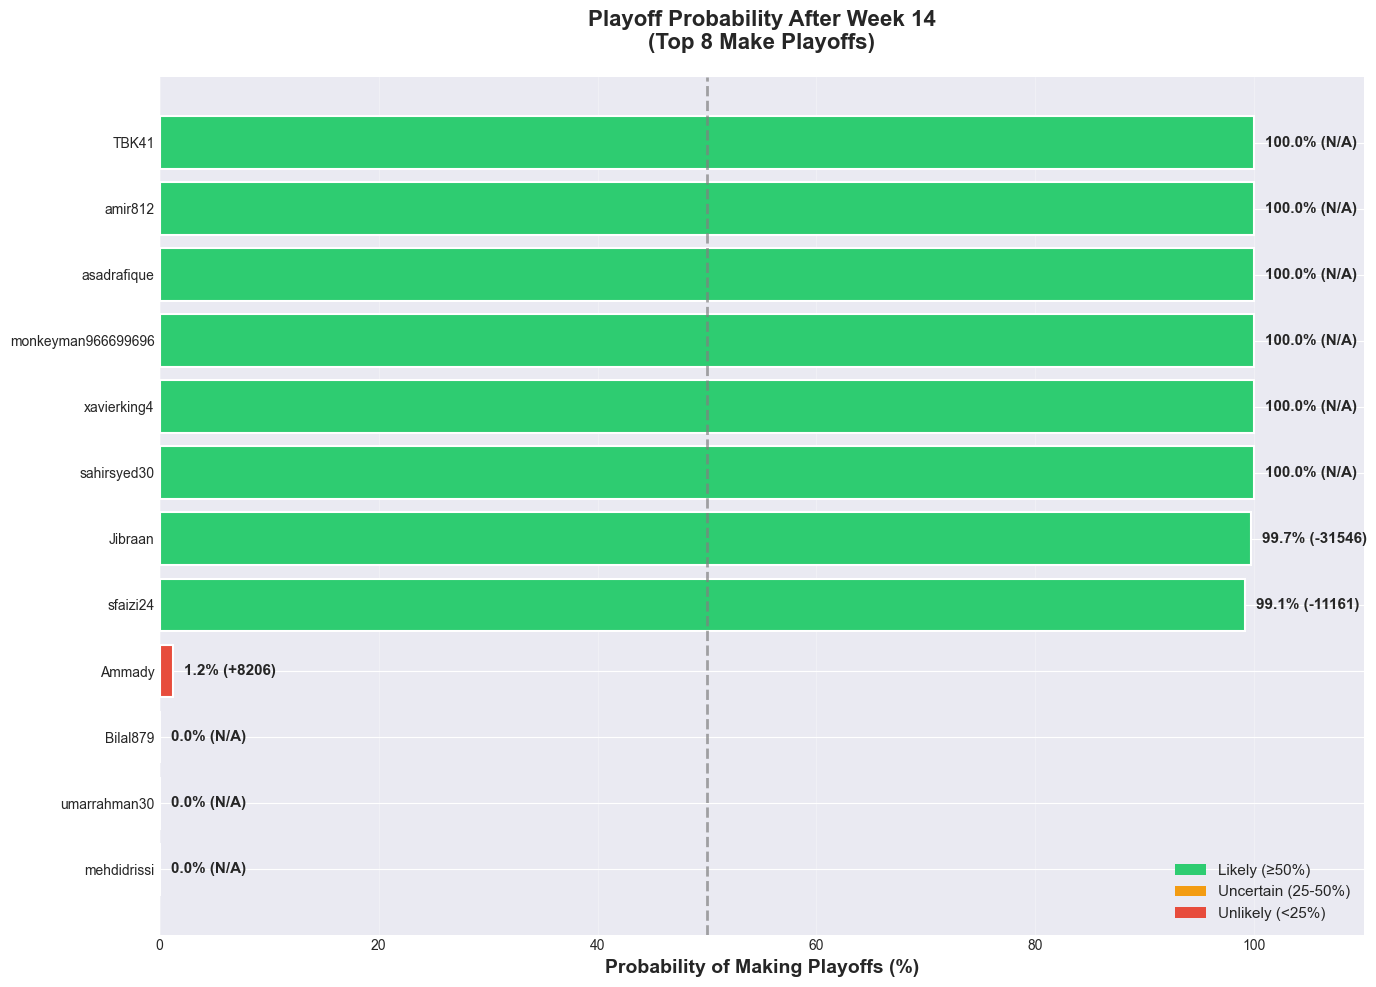

💾 Saved: playoff_probability_week_14.png


In [11]:
# Sort by playoff probability
df_viz = df_playoff_odds.sort_values('top8_prob', ascending=True)

fig, ax = plt.subplots(figsize=(14, 10))

# Color bars by playoff status
colors = ['#2ecc71' if p >= 0.5 else '#e74c3c' if p < 0.25 else '#f39c12' 
          for p in df_viz['top8_prob']]

bars = ax.barh(df_viz['owner'], df_viz['top8_prob'] * 100, color=colors, edgecolor='white', linewidth=1.5)

# Add probability labels
for bar, prob, odds in zip(bars, df_viz['top8_prob'], df_viz['top8_odds']):
    width = bar.get_width()
    label_x = width + 1
    ax.text(label_x, bar.get_y() + bar.get_height()/2, 
            f'{prob*100:.1f}% ({odds})', 
            va='center', ha='left', fontsize=11, fontweight='bold')

# Add 50% line
ax.axvline(x=50, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='50% threshold')

ax.set_xlabel('Probability of Making Playoffs (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_title(f'Playoff Probability After Week {CURRENT_WEEK}\n(Top {PLAYOFF_CUTOFF} Make Playoffs)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Likely (≥50%)'),
    Patch(facecolor='#f39c12', label='Uncertain (25-50%)'),
    Patch(facecolor='#e74c3c', label='Unlikely (<25%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig(str(IMAGES_DIR / f'playoff_probability_week_{CURRENT_WEEK}.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved: playoff_probability_week_{CURRENT_WEEK}.png")


---
## 📊 Visualization: #1 Seed Race


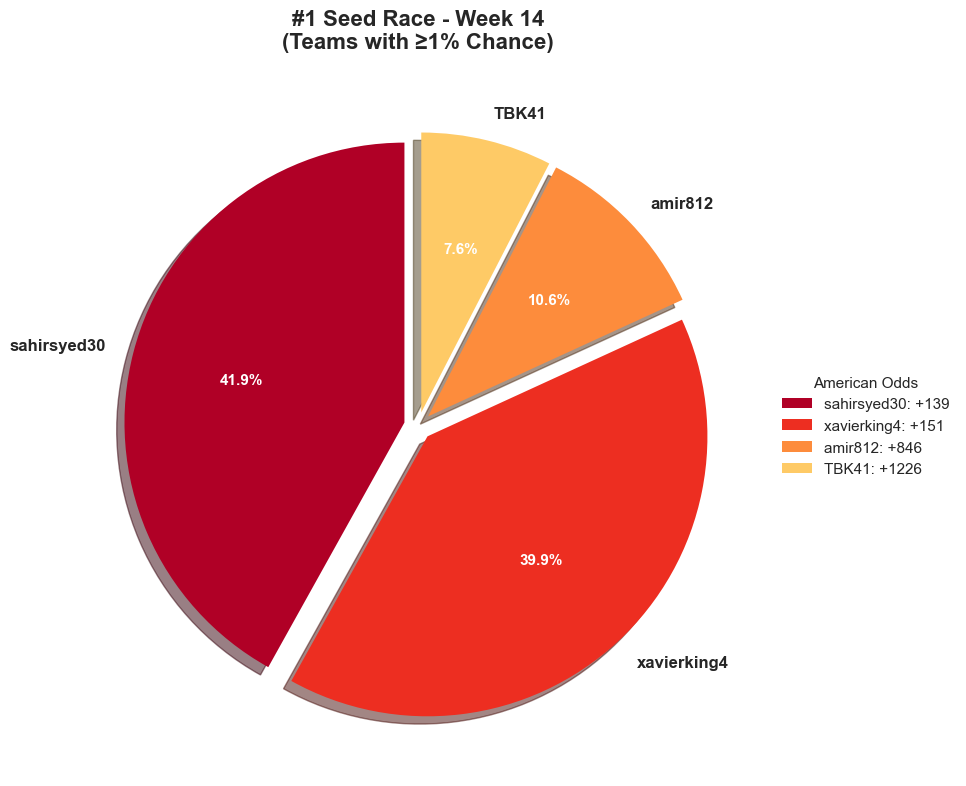

💾 Saved: first_place_race_week_14.png


In [13]:
# Filter to teams with realistic #1 seed chances (>1%)
df_top_contenders = df_playoff_odds[df_playoff_odds['first_place_prob'] >= 0.01].sort_values('first_place_prob', ascending=False)

if len(df_top_contenders) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Gradient colors from gold to silver
    n_teams = len(df_top_contenders)
    colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, n_teams))[::-1]
    
    wedges, texts, autotexts = ax.pie(
        df_top_contenders['first_place_prob'],
        labels=df_top_contenders['owner'],
        autopct=lambda pct: f'{pct:.1f}%' if pct >= 3 else '',
        colors=colors,
        explode=[0.05] * n_teams,
        shadow=True,
        startangle=90
    )
    
    # Style the text
    for text in texts:
        text.set_fontsize(12)
        text.set_fontweight('bold')
    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    ax.set_title(f'#1 Seed Race - Week {CURRENT_WEEK}\n(Teams with ≥1% Chance)', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Add odds as legend
    legend_labels = [f"{row['owner']}: {row['first_place_odds']}" 
                     for _, row in df_top_contenders.iterrows()]
    ax.legend(wedges, legend_labels, title="American Odds", loc="center left", 
              bbox_to_anchor=(1, 0, 0.5, 1), fontsize=11)
    
    plt.tight_layout()
    plt.savefig(str(IMAGES_DIR / f'first_place_race_week_{CURRENT_WEEK}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved: first_place_race_week_{CURRENT_WEEK}.png")
else:
    print("⚠️ No teams have realistic #1 seed chances to display")


---
## 📊 Visualization: Standings Distribution Range


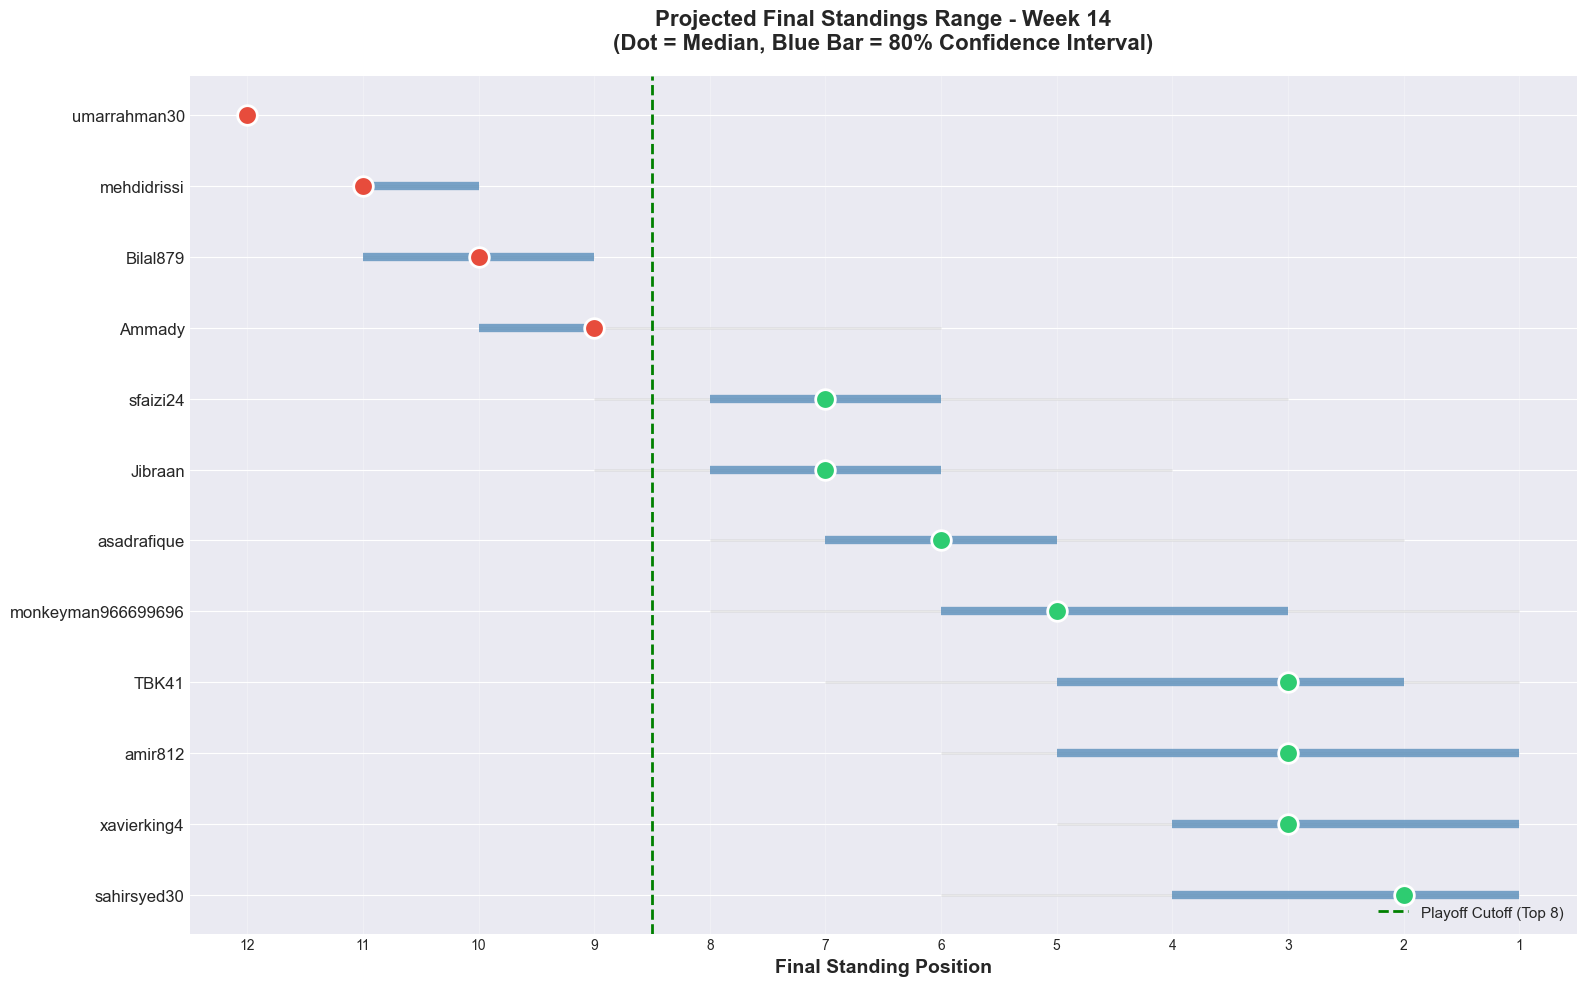

💾 Saved: standings_range_week_14.png


In [14]:
# Create box plot style visualization for standings distribution
fig, ax = plt.subplots(figsize=(16, 10))

# Prepare data for visualization
viz_data = []
for team_id in teams:
    owner = current_standings[team_id]['owner']
    
    # Calculate weighted average position (expected finish)
    positions_weighted = sum(pos * standings_count[team_id][pos] for pos in range(1, 13)) / n_sims
    
    # Find 10th and 90th percentile positions
    cumsum = 0
    p10 = p90 = median = None
    for pos in range(1, 13):
        cumsum += standings_count[team_id][pos]
        if p10 is None and cumsum >= n_sims * 0.10:
            p10 = pos
        if median is None and cumsum >= n_sims * 0.50:
            median = pos
        if p90 is None and cumsum >= n_sims * 0.90:
            p90 = pos
            break
    
    # Find mode (most likely position)
    mode = max(range(1, 13), key=lambda x: standings_count[team_id][x])
    
    viz_data.append({
        'owner': owner,
        'expected': positions_weighted,
        'median': median,
        'mode': mode,
        'p10': p10,
        'p90': p90,
        'best': min(pos for pos in range(1, 13) if standings_count[team_id][pos] > 0),
        'worst': max(pos for pos in range(1, 13) if standings_count[team_id][pos] > 0)
    })

df_viz_positions = pd.DataFrame(viz_data).sort_values('expected')

# Plot
y_positions = range(len(df_viz_positions))

# Draw range bars (best to worst)
for idx, (_, row) in enumerate(df_viz_positions.iterrows()):
    # Full range (thin line)
    ax.hlines(y=idx, xmin=row['best'], xmax=row['worst'], color='lightgray', linewidth=2, alpha=0.5)
    
    # 80% confidence interval (thicker line)
    ax.hlines(y=idx, xmin=row['p10'], xmax=row['p90'], color='steelblue', linewidth=6, alpha=0.7)
    
    # Median point
    color = '#2ecc71' if row['median'] <= PLAYOFF_CUTOFF else '#e74c3c'
    ax.scatter(row['median'], idx, color=color, s=200, zorder=5, edgecolor='white', linewidth=2)

# Add playoff line
ax.axvline(x=PLAYOFF_CUTOFF + 0.5, color='green', linestyle='--', linewidth=2, 
           label=f'Playoff Cutoff (Top {PLAYOFF_CUTOFF})')

ax.set_yticks(y_positions)
ax.set_yticklabels(df_viz_positions['owner'], fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Final Standing Position', fontsize=14, fontweight='bold')
ax.set_title(f'Projected Final Standings Range - Week {CURRENT_WEEK}\n'
             f'(Dot = Median, Blue Bar = 80% Confidence Interval)', 
             fontsize=16, fontweight='bold', pad=20)
ax.invert_xaxis()  # Best positions on left
ax.set_xlim(12.5, 0.5)
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig(str(IMAGES_DIR / f'standings_range_week_{CURRENT_WEEK}.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved: standings_range_week_{CURRENT_WEEK}.png")


---
## 📊 Visualization: Playoff Betting Board


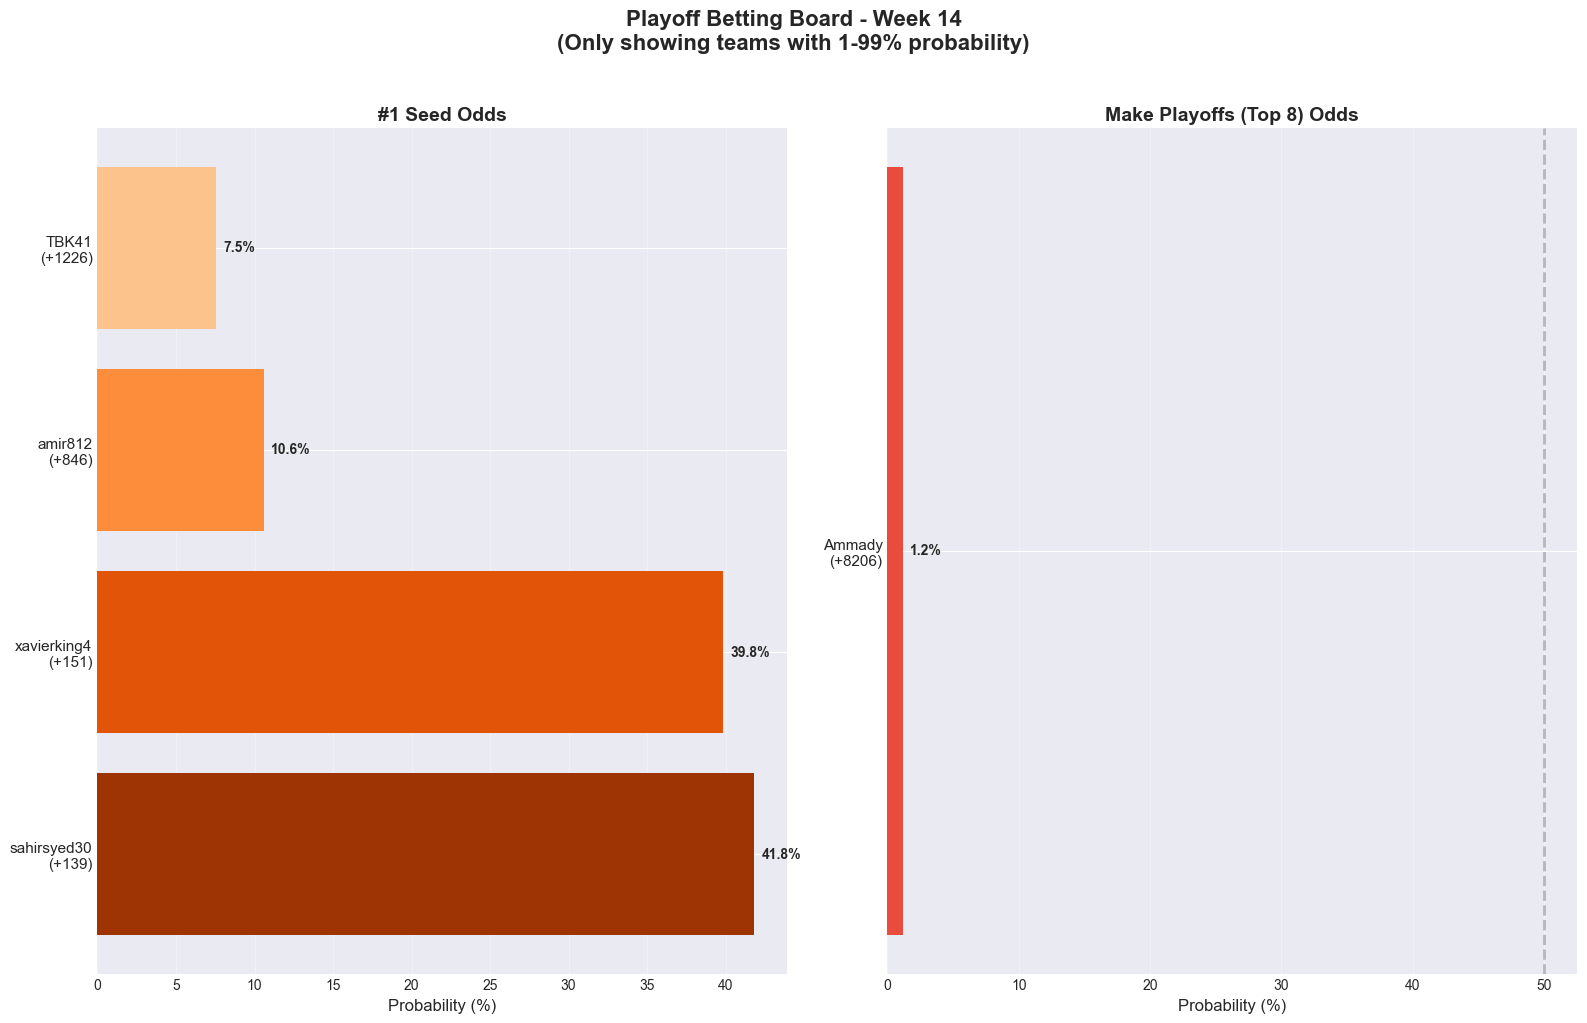

💾 Saved: playoff_betting_board_week_14.png


In [16]:
# Create a "betting board" style visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Filter to 1-99% range for display
df_first = df_playoff_odds[(df_playoff_odds['first_place_prob'] >= 0.01) & 
                           (df_playoff_odds['first_place_prob'] <= 0.99)].sort_values('first_place_prob', ascending=False)

df_playoffs = df_playoff_odds[(df_playoff_odds['top8_prob'] >= 0.01) & 
                              (df_playoff_odds['top8_prob'] <= 0.99)].sort_values('top8_prob', ascending=False)

# Left panel: #1 Seed odds
ax1 = axes[0]
if len(df_first) > 0:
    y_pos = range(len(df_first))
    colors = plt.cm.Oranges(np.linspace(0.3, 0.9, len(df_first)))[::-1]
    bars = ax1.barh(y_pos, df_first['first_place_prob'] * 100, color=colors)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels([f"{row['owner']}\n({row['first_place_odds']})" 
                         for _, row in df_first.iterrows()], fontsize=11)
    
    for bar, prob in zip(bars, df_first['first_place_prob']):
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{prob*100:.1f}%', va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Probability (%)', fontsize=12)
ax1.set_title('#1 Seed Odds', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Right panel: Make Playoffs odds
ax2 = axes[1]
if len(df_playoffs) > 0:
    y_pos = range(len(df_playoffs))
    colors = ['#2ecc71' if p >= 0.5 else '#f39c12' if p >= 0.25 else '#e74c3c' 
              for p in df_playoffs['top8_prob']]
    bars = ax2.barh(y_pos, df_playoffs['top8_prob'] * 100, color=colors)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([f"{row['owner']}\n({row['top8_odds']})" 
                         for _, row in df_playoffs.iterrows()], fontsize=11)
    
    for bar, prob in zip(bars, df_playoffs['top8_prob']):
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{prob*100:.1f}%', va='center', fontsize=10, fontweight='bold')

ax2.axvline(x=50, color='gray', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Probability (%)', fontsize=12)
ax2.set_title(f'Make Playoffs (Top {PLAYOFF_CUTOFF}) Odds', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

fig.suptitle(f'Playoff Betting Board - Week {CURRENT_WEEK}\n(Only showing teams with 1-99% probability)',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(str(IMAGES_DIR / f'playoff_betting_board_week_{CURRENT_WEEK}.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved: playoff_betting_board_week_{CURRENT_WEEK}.png")


---
## 📋 Summary


In [17]:
print("\n" + "="*70)
print("📊 PLAYOFF ODDS SUMMARY")
print("="*70)

print(f"\n🏆 #1 SEED CONTENDERS (1-99% range):")
for _, row in df_playoff_odds[df_playoff_odds['first_place_prob'] >= 0.01].sort_values('first_place_prob', ascending=False).iterrows():
    if row['first_place_prob'] <= 0.99:
        print(f"   {row['owner']:<20} {row['first_place_prob']*100:>6.1f}%  ({row['first_place_odds']})")

print(f"\n✅ PLAYOFF LOCKS (>99%):")
locks = df_playoff_odds[df_playoff_odds['top8_prob'] > 0.99]
if len(locks) > 0:
    for _, row in locks.iterrows():
        print(f"   {row['owner']}")
else:
    print("   None - all spots still up for grabs!")

print(f"\n❌ ELIMINATED (<1% playoff chance):")
eliminated = df_playoff_odds[df_playoff_odds['top8_prob'] < 0.01]
if len(eliminated) > 0:
    for _, row in eliminated.iterrows():
        print(f"   {row['owner']}")
else:
    print("   None - everyone still has a chance!")

print(f"\n⚔️ BUBBLE TEAMS (25-75% playoff chance):")
bubble = df_playoff_odds[(df_playoff_odds['top8_prob'] >= 0.25) & 
                         (df_playoff_odds['top8_prob'] <= 0.75)].sort_values('top8_prob', ascending=False)
for _, row in bubble.iterrows():
    print(f"   {row['owner']:<20} {row['top8_prob']*100:>6.1f}%  ({row['top8_odds']})")

print("\n" + "="*70)
print(f"💾 All data saved to: {DB_ODDS_PATH}")
print(f"🖼️ Visualizations saved to: {IMAGES_DIR}")
print("="*70)



📊 PLAYOFF ODDS SUMMARY

🏆 #1 SEED CONTENDERS (1-99% range):
   sahirsyed30            41.8%  (+139)
   xavierking4            39.8%  (+151)
   amir812                10.6%  (+846)
   TBK41                   7.5%  (+1226)

✅ PLAYOFF LOCKS (>99%):
   sahirsyed30
   xavierking4
   amir812
   TBK41
   monkeyman966699696
   asadrafique
   Jibraan
   sfaizi24

❌ ELIMINATED (<1% playoff chance):
   Bilal879
   mehdidrissi
   umarrahman30

⚔️ BUBBLE TEAMS (25-75% playoff chance):

💾 All data saved to: C:\Users\Samer Faizi\Documents\Claude Model\backend\data\databases\odds.db
🖼️ Visualizations saved to: C:\Users\Samer Faizi\Documents\Claude Model\backend\data\images
